# SisFall — Check Windowed Dataset + Train CNN-LSTM 6-axis

Notebook này được viết cho dataset:

`https://drive.google.com/file/d/1MAmYTi0VI40eQeedAe0GEkdJ0zpnEZxr/view?usp=drive_link`

File đã được xác định ở **root của My Drive** với tên:

`SisFall_dataset_Windowed.zip`

Pipeline mong đợi theo repo:

- SisFall raw: 200 Hz
- preprocess: downsample xuống 100 Hz
- đơn vị:
  - ADXL: `g`
  - ITG: `deg/s`
- input model: 6 kênh  
  `ADXL_X, ADXL_Y, ADXL_Z, ITG_X, ITG_Y, ITG_Z`
- mỗi window: `200 samples = 2 giây`
- ADL: sliding window, `step = 50 samples` → overlap 150 samples = 75%
- Fall: tối đa 5 window quanh đỉnh `sqrt(ax² + ay² + az²)`, dịch 50 samples
- Train/Val/Test: chia theo **subject**, không random window.

> Mục tiêu notebook: trước tiên **kiểm tra dataset**, chỉ train khi dataset pass.

## 0. Trước khi chạy

Trong Colab chọn:

**Runtime → Change runtime type → T4 GPU**

Sau đó chạy từng cell từ trên xuống.

## 1. Mount Google Drive

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Sau khi mount, file của bạn đang nằm ở root My Drive nên đường dẫn mặc định là:

`/content/drive/MyDrive/SisFall_dataset_Windowed.zip`

Cell dưới sẽ kiểm tra đúng file trước khi làm tiếp.

In [5]:
from pathlib import Path
import os

ZIP_PATH = Path("/content/drive/MyDrive/SisFall_dataset_Windowed.zip")

if not ZIP_PATH.exists():
    raise FileNotFoundError(
        f"Không thấy file tại:\n{ZIP_PATH}\n\n"
        "Hãy kiểm tra file có nằm ở root My Drive và đúng tên "
        "SisFall_dataset_Windowed.zip hay không."
    )

size_gb = ZIP_PATH.stat().st_size / (1024**3)

print("✅ Tìm thấy dataset")
print("Path :", ZIP_PATH)
print(f"Size : {size_gb:.3f} GiB")

✅ Tìm thấy dataset
Path : /content/drive/MyDrive/SisFall_dataset_Windowed.zip
Size : 1.749 GiB


## 2. Giải nén vào local disk của Colab

Không train trực tiếp hàng trăm nghìn CSV từ Google Drive vì I/O sẽ chậm.  
Ta giải nén sang `/content`, sau đó đọc từ local disk.

In [3]:
import zipfile
import shutil
from pathlib import Path

EXTRACT_ROOT = Path("/content/SisFall_dataset_Windowed")

# Nếu đã giải nén từ lần chạy trước thì không làm lại.
csv_existing = list(EXTRACT_ROOT.rglob("*.csv")) if EXTRACT_ROOT.exists() else []

if csv_existing:
    print(f"✅ Dataset đã được giải nén: {len(csv_existing):,} CSV")
else:
    if EXTRACT_ROOT.exists():
        shutil.rmtree(EXTRACT_ROOT)
    EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

    if not zipfile.is_zipfile(ZIP_PATH):
        raise ValueError("File không phải ZIP hợp lệ.")

    print("Đang giải nén...")
    with zipfile.ZipFile(ZIP_PATH, "r") as z:
        z.extractall(EXTRACT_ROOT)

    print("✅ Giải nén xong")

Đang giải nén...
✅ Giải nén xong


## 3. Tìm CSV và xem cấu trúc thư mục

In [6]:
from pathlib import Path

ALL_FILES = sorted(EXTRACT_ROOT.rglob("*.csv"))

print(f"Tổng CSV: {len(ALL_FILES):,}")

if not ALL_FILES:
    raise RuntimeError("❌ Không tìm thấy CSV trong dataset đã giải nén.")

print("\n10 file đầu:")
for p in ALL_FILES[:10]:
    print(" -", p.relative_to(EXTRACT_ROOT))

Tổng CSV: 105,501

10 file đầu:
 - sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W000.csv
 - sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W001.csv
 - sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W002.csv
 - sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W003.csv
 - sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W004.csv
 - sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W005.csv
 - sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W006.csv
 - sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W007.csv
 - sis_fall_har_and_fall-detection_trainning-main/SisFall_dataset_Windowed/SA01/D01_SA01_R01_W008.csv
 - sis_fall_har_and_fall-detection_trainning-main/

## 4. Cấu hình chuẩn dùng để train

Repo preprocess lưu **9 cột**:

- ADXL_X/Y/Z
- ITG_X/Y/Z
- MMA_X/Y/Z

Nhưng model chạy với MPU6050/MPU6500 của bạn chỉ cần **6 cột** đầu tiên.

Vì vậy CSV có 9 cột là **đúng**, còn input model cuối cùng phải là `(200, 6)`.

In [7]:
import numpy as np
import pandas as pd
import re

WINDOW_SIZE = 200
SAMPLE_RATE_HZ = 100
STEP_SIZE = 50

REQUIRED_COLUMNS = [
    "ADXL_X", "ADXL_Y", "ADXL_Z",
    "ITG_X", "ITG_Y", "ITG_Z",
]

EXPECTED_ALL_COLUMNS = [
    "ADXL_X", "ADXL_Y", "ADXL_Z",
    "ITG_X", "ITG_Y", "ITG_Z",
    "MMA_X", "MMA_Y", "MMA_Z",
]

print("Window =", WINDOW_SIZE, "samples")
print("Duration =", WINDOW_SIZE / SAMPLE_RATE_HZ, "seconds")
print("Step =", STEP_SIZE, "samples")
print("Inference stride tương đương =", STEP_SIZE / SAMPLE_RATE_HZ, "seconds")

Window = 200 samples
Duration = 2.0 seconds
Step = 50 samples
Inference stride tương đương = 0.5 seconds


## 5. Đọc thử 1 window

In [8]:
sample_path = ALL_FILES[0]
df = pd.read_csv(sample_path)

print("File   :", sample_path.name)
print("Shape  :", df.shape)
print("Columns:", df.columns.tolist())

display(df.head())

missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]

assert len(df) == 200, f"❌ Window đầu tiên có {len(df)} rows, không phải 200."
assert not missing, f"❌ Thiếu cột: {missing}"

x6 = df[REQUIRED_COLUMNS].to_numpy(dtype=np.float32)

print("\n6-axis input shape:", x6.shape)
print("\nMin:")
print(pd.Series(x6.min(axis=0), index=REQUIRED_COLUMNS))
print("\nMax:")
print(pd.Series(x6.max(axis=0), index=REQUIRED_COLUMNS))

File   : D01_SA01_R01_W000.csv
Shape  : (200, 9)
Columns: ['ADXL_X', 'ADXL_Y', 'ADXL_Z', 'ITG_X', 'ITG_Y', 'ITG_Z', 'MMA_X', 'MMA_Y', 'MMA_Z']


,ADXL_X,ADXL_Y,ADXL_Z,ITG_X,ITG_Y,ITG_Z,MMA_X,MMA_Y,MMA_Z
0,0.065605,-0.691335,-0.382251,-1.085305,-30.402252,-21.230387,0.073315,-0.672907,-0.269363
1,0.013294,-0.671235,-0.316923,-5.101883,-37.102333,-16.114840,0.004168,-0.646187,-0.211042
2,-0.093874,-0.756336,-0.253578,-7.841714,-40.849801,-11.565621,-0.074928,-0.721655,-0.129822
3,-0.149966,-0.946431,-0.181087,-10.231069,-43.617800,-7.775312,-0.138984,-0.916831,-0.068767
4,-0.197604,-1.191396,-0.118178,-12.895439,-45.573548,-5.430677,-0.196215,-1.153713,0.003422



6-axis input shape: (200, 6)

Min:
ADXL_X    -0.397234
ADXL_Y    -1.624811
ADXL_Z    -0.592984
ITG_X    -36.448170
ITG_Y    -58.956337
ITG_Z    -65.049278
dtype: float32

Max:
ADXL_X     0.473109
ADXL_Y    -0.671235
ADXL_Z     0.296645
ITG_X     58.113293
ITG_Y     64.465797
ITG_Z     58.119576
dtype: float32


# PHẦN A — KIỂM TRA DATASET WINDOWED

Ta kiểm tra 5 thứ:

1. Tên file có đúng format `D01_SA01_R01_W000.csv`.
2. Mỗi CSV có đúng 200 dòng.
3. Có đủ 6 cột dùng để train.
4. Không NaN/Inf, giá trị vật lý không vô lý.
5. Các window liên tiếp có overlap đúng 150 mẫu (`step = 50`).

## 6. Validator toàn bộ CSV

In [9]:
from concurrent.futures import ThreadPoolExecutor
from collections import Counter
import numpy as np
import pandas as pd
import re

# Chấp nhận format:
# D01_SA01_R01_W000.csv
# F15_SE15_R05_W004.csv
NAME_RE = re.compile(
    r"^(D\d{2}|F\d{2})_(SA\d{2}|SE\d{2})_R\d{2}_W\d{3}$"
)

VALID_D = {f"D{i:02d}" for i in range(1, 20)}
VALID_F = {f"F{i:02d}" for i in range(1, 16)}
VALID_LABEL_CODES = VALID_D | VALID_F

VALID_SA = {f"SA{i:02d}" for i in range(1, 24)}
VALID_SE = {f"SE{i:02d}" for i in range(1, 16)}
VALID_SUBJECTS = VALID_SA | VALID_SE

def parse_window_name(path):
    m = NAME_RE.match(path.stem)
    if not m:
        return None
    label_code, subject = m.group(1), m.group(2)
    return label_code, subject

def validate_one(path):
    parsed = parse_window_name(path)
    if parsed is None:
        return False, "bad_filename", path.name

    label_code, subject = parsed

    if label_code not in VALID_LABEL_CODES:
        return False, f"invalid_label:{label_code}", path.name

    if subject not in VALID_SUBJECTS:
        return False, f"invalid_subject:{subject}", path.name

    try:
        df = pd.read_csv(path)
    except Exception as e:
        return False, f"read_error:{type(e).__name__}", path.name

    if len(df) != WINDOW_SIZE:
        return False, f"wrong_rows:{len(df)}", path.name

    missing = [c for c in REQUIRED_COLUMNS if c not in df.columns]
    if missing:
        return False, "missing_columns:" + ",".join(missing), path.name

    try:
        x = df[REQUIRED_COLUMNS].to_numpy(dtype=np.float32)
    except Exception as e:
        return False, f"not_numeric:{type(e).__name__}", path.name

    if x.shape != (WINDOW_SIZE, 6):
        return False, f"wrong_shape:{x.shape}", path.name

    if not np.isfinite(x).all():
        return False, "nan_or_inf", path.name

    # Sanity bounds.
    # ADXL345 preprocess dùng range +-16g.
    # ITG3200 dùng range +-2000 deg/s.
    # Chừa margin do filter/rounding.
    accel = x[:, :3]
    gyro  = x[:, 3:]

    if np.max(np.abs(accel)) > 20.0:
        return False, f"accel_out_of_range:{np.max(np.abs(accel)):.3f}", path.name

    if np.max(np.abs(gyro)) > 2500.0:
        return False, f"gyro_out_of_range:{np.max(np.abs(gyro)):.3f}", path.name

    return True, "ok", path.name

print(f"Đang validate {len(ALL_FILES):,} files...")

errors = Counter()
bad_examples = []
valid_count = 0

with ThreadPoolExecutor(max_workers=12) as ex:
    for i, result in enumerate(ex.map(validate_one, ALL_FILES), start=1):
        ok, reason, name = result

        if ok:
            valid_count += 1
        else:
            errors[reason] += 1
            if len(bad_examples) < 30:
                bad_examples.append((name, reason))

        if i % 10000 == 0:
            print(f"  {i:,}/{len(ALL_FILES):,}")

print("\n" + "="*60)
print("DATASET STRUCTURE REPORT")
print("="*60)
print(f"Total   : {len(ALL_FILES):,}")
print(f"Valid   : {valid_count:,}")
print(f"Invalid : {len(ALL_FILES) - valid_count:,}")

if errors:
    print("\nError counts:")
    for reason, n in errors.most_common():
        print(f"  {reason}: {n:,}")

if bad_examples:
    print("\nVí dụ file lỗi:")
    for item in bad_examples:
        print(" ", item)

STRUCTURE_PASS = (valid_count == len(ALL_FILES) and len(ALL_FILES) > 0)

if STRUCTURE_PASS:
    print("\n✅ PASS: toàn bộ CSV đạt format cơ bản 200 × 6-axis.")
else:
    print("\n❌ FAIL: dataset còn file lỗi. Chưa nên train.")

Đang validate 105,501 files...
  10,000/105,501
  20,000/105,501
  30,000/105,501
  40,000/105,501
  50,000/105,501
  60,000/105,501
  70,000/105,501
  80,000/105,501
  90,000/105,501
  100,000/105,501

DATASET STRUCTURE REPORT
Total   : 105,501
Valid   : 105,501
Invalid : 0

✅ PASS: toàn bộ CSV đạt format cơ bản 200 × 6-axis.


## 7. Kiểm tra số lượng label / subject

Cell này giúp phát hiện trường hợp:

- thiếu subject;
- thiếu action;
- một phần dataset bị mất khi zip/copy.

In [10]:
from collections import Counter

label_counts = Counter()
subject_counts = Counter()
recording_counts = Counter()

for p in ALL_FILES:
    parsed = parse_window_name(p)
    if not parsed:
        continue

    label, subject = parsed
    label_counts[label] += 1
    subject_counts[subject] += 1

    parts = p.stem.split("_")
    if len(parts) >= 3:
        recording_counts["_".join(parts[:3])] += 1

print("Subjects:", len(subject_counts))
print("Recordings:", len(recording_counts))
print("Labels:", len(label_counts))

print("\nSubjects:")
for k in sorted(subject_counts):
    print(f"{k}: {subject_counts[k]:,}")

print("\nLabel codes:")
for k in sorted(label_counts):
    print(f"{k}: {label_counts[k]:,}")

Subjects: 38
Recordings: 4500
Labels: 34

Subjects:
SA01: 3,128
SA02: 3,128
SA03: 3,128
SA04: 3,128
SA05: 3,128
SA06: 3,128
SA07: 3,128
SA08: 3,128
SA09: 3,128
SA10: 3,128
SA11: 3,128
SA12: 3,128
SA13: 3,128
SA14: 3,128
SA15: 2,893
SA16: 3,128
SA17: 3,080
SA18: 3,128
SA19: 3,125
SA20: 3,020
SA21: 3,128
SA22: 3,125
SA23: 3,128
SE01: 2,775
SE02: 1,710
SE03: 2,209
SE04: 2,129
SE05: 2,149
SE06: 3,128
SE07: 2,201
SE08: 2,203
SE09: 2,202
SE10: 2,203
SE11: 2,203
SE12: 2,198
SE13: 2,203
SE14: 2,200
SE15: 2,241

Label codes:
D01: 7,643
D02: 7,646
D03: 7,644
D04: 7,268
D05: 8,928
D06: 5,545
D07: 3,990
D08: 3,989
D09: 3,884
D10: 3,884
D11: 3,974
D12: 3,990
D13: 2,519
D14: 3,990
D15: 3,969
D16: 3,968
D17: 8,642
D18: 2,518
D19: 2,520
F01: 595
F02: 600
F03: 600
F04: 600
F05: 600
F06: 600
F07: 600
F08: 600
F09: 600
F10: 595
F11: 600
F12: 600
F13: 600
F14: 600
F15: 600


## 8. Kiểm tra overlap `200 / step 50`

Repo cắt:

```python
window_size = 200
step_size = 50
```

Do đó hai window liên tiếp cùng recording phải thỏa:

`window_A[50:200] == window_B[0:150]`

Ta kiểm tra tối đa 2000 recording để tránh đọc lại toàn bộ dataset hai lần.

In [11]:
from collections import defaultdict
import numpy as np
import pandas as pd

def recording_key(path):
    # D01_SA01_R01_W003 -> D01_SA01_R01
    return "_".join(path.stem.split("_")[:3])

groups = defaultdict(list)

for p in ALL_FILES:
    groups[recording_key(p)].append(p)

checked_pairs = 0
matched_pairs = 0
bad_overlap = []

MAX_GROUPS_TO_CHECK = 2000
checked_groups = 0

for key in sorted(groups):
    files = sorted(groups[key])

    if len(files) < 2:
        continue

    # Kiểm tra tất cả cặp liên tiếp trong recording được sample.
    group_ok = True

    for a_path, b_path in zip(files[:-1], files[1:]):
        a = pd.read_csv(a_path, usecols=REQUIRED_COLUMNS)[REQUIRED_COLUMNS].to_numpy(np.float32)
        b = pd.read_csv(b_path, usecols=REQUIRED_COLUMNS)[REQUIRED_COLUMNS].to_numpy(np.float32)

        checked_pairs += 1

        if np.allclose(a[STEP_SIZE:], b[:WINDOW_SIZE-STEP_SIZE],
                       rtol=1e-6, atol=1e-6):
            matched_pairs += 1
        else:
            group_ok = False
            if len(bad_overlap) < 20:
                bad_overlap.append((key, a_path.name, b_path.name))

    checked_groups += 1

    if checked_groups >= MAX_GROUPS_TO_CHECK:
        break

ratio = matched_pairs / checked_pairs if checked_pairs else 0.0

print("Groups checked :", checked_groups)
print("Pairs checked  :", checked_pairs)
print("Pairs matched  :", matched_pairs)
print(f"Overlap ratio  : {ratio*100:.3f}%")

if bad_overlap:
    print("\nVí dụ overlap sai:")
    for x in bad_overlap:
        print(" ", x)

OVERLAP_PASS = checked_pairs > 0 and ratio >= 0.995

if OVERLAP_PASS:
    print("\n✅ PASS: overlap phù hợp step=50.")
else:
    print("\n⚠️ CHECK: overlap chưa đạt kỳ vọng.")

Groups checked : 2000
Pairs checked  : 75036
Pairs matched  : 75036
Overlap ratio  : 100.000%

✅ PASS: overlap phù hợp step=50.


## 9. Kiểm tra riêng Fall window quanh peak

Theo `windowing_pipeline.py`:

```python
svm = sqrt(ADXL_X² + ADXL_Y² + ADXL_Z²)
peak_idx = svm.argmax()
shifts = [-100, -50, 0, 50, 100]
```

Mỗi recording Fall chỉ nên có tối đa **5 window**.

Ngoài ra nếu đủ 5 window và overlap đúng, sau khi ghép lại thành chuỗi 400 mẫu,
global peak phải nằm quanh vị trí 200. Đây là dấu hiệu rất mạnh rằng Fall đã được
cắt đúng quanh impact peak.

In [12]:
fall_groups = {
    k: sorted(v)
    for k, v in groups.items()
    if k.startswith("F")
}

fall_window_count_errors = []
five_window_checked = 0
five_window_peak_ok = 0
five_window_bad_examples = []

for key, files in fall_groups.items():
    if len(files) > 5:
        fall_window_count_errors.append((key, len(files)))
        continue

    if len(files) != 5:
        continue

    # reconstruct: full first window + 50 new samples từ mỗi window tiếp theo
    arrays = [
        pd.read_csv(p, usecols=REQUIRED_COLUMNS)[REQUIRED_COLUMNS].to_numpy(np.float32)
        for p in files
    ]

    # Chỉ kiểm tra nếu overlap thực sự đúng.
    overlap_ok = all(
        np.allclose(arrays[i][50:], arrays[i+1][:150], rtol=1e-6, atol=1e-6)
        for i in range(4)
    )
    if not overlap_ok:
        continue

    merged = np.concatenate(
        [arrays[0]] + [a[-50:] for a in arrays[1:]],
        axis=0
    )  # 200 + 4*50 = 400

    svm = np.linalg.norm(merged[:, :3], axis=1)
    peak = int(np.argmax(svm))

    five_window_checked += 1

    # Với 5 shifts đầy đủ, peak gốc nằm ở union index ~200.
    if abs(peak - 200) <= 2:
        five_window_peak_ok += 1
    elif len(five_window_bad_examples) < 20:
        five_window_bad_examples.append((key, peak, float(svm[peak])))

print("Fall recordings:", len(fall_groups))
print("Fall recordings >5 windows:", len(fall_window_count_errors))
print("5-window groups checked:", five_window_checked)

if five_window_checked:
    peak_ratio = five_window_peak_ok / five_window_checked
    print(f"Peak at center ratio: {peak_ratio*100:.3f}%")
else:
    peak_ratio = 0.0

if fall_window_count_errors[:10]:
    print("\nRecording có >5 Fall windows:")
    for x in fall_window_count_errors[:10]:
        print(" ", x)

if five_window_bad_examples:
    print("\nVí dụ peak không ở ~200:")
    for x in five_window_bad_examples:
        print(" ", x)

FALL_PASS = (
    len(fall_window_count_errors) == 0
    and (
        five_window_checked == 0
        or peak_ratio >= 0.98
    )
)

if FALL_PASS:
    print("\n✅ PASS: Fall windowing phù hợp logic quanh SVM peak.")
else:
    print("\n⚠️ CHECK: Fall windowing có điểm chưa khớp pipeline.")

Fall recordings: 1798
Fall recordings >5 windows: 0
5-window groups checked: 1798
Peak at center ratio: 100.000%

✅ PASS: Fall windowing phù hợp logic quanh SVM peak.


## 10. Sanity check đơn vị vật lý

Sau preprocess:

- ADXL phải là `g`
- ITG phải là `deg/s`

Ta sample một số window và xem phân bố.

Không yêu cầu `sqrt(ax²+ay²+az²)` luôn bằng 1 vì lúc di chuyển/ngã có dynamic acceleration.
Nhưng dữ liệu không nên còn ở dạng raw ADC hàng nghìn/hàng chục nghìn.

In [13]:
import random
import numpy as np
import pandas as pd

rng = random.Random(42)
sample_files = rng.sample(ALL_FILES, min(2000, len(ALL_FILES)))

acc_abs = []
gyro_abs = []
acc_norms = []

for p in sample_files:
    x = pd.read_csv(
        p,
        usecols=REQUIRED_COLUMNS
    )[REQUIRED_COLUMNS].to_numpy(np.float32)

    acc = x[:, :3]
    gyro = x[:, 3:]

    acc_abs.append(np.abs(acc).reshape(-1))
    gyro_abs.append(np.abs(gyro).reshape(-1))
    acc_norms.append(np.linalg.norm(acc, axis=1))

acc_abs = np.concatenate(acc_abs)
gyro_abs = np.concatenate(gyro_abs)
acc_norms = np.concatenate(acc_norms)

print("Accel |value| percentiles (g):")
print(np.percentile(acc_abs, [50, 90, 95, 99, 99.9]))

print("\nGyro |value| percentiles (deg/s):")
print(np.percentile(gyro_abs, [50, 90, 95, 99, 99.9]))

print("\nAccel norm percentiles (g):")
print(np.percentile(acc_norms, [10, 50, 90, 95, 99, 99.9]))

# Cảnh báo mạnh nếu dữ liệu có vẻ vẫn là raw ADC.
median_acc_abs = float(np.median(acc_abs))
UNIT_PASS = median_acc_abs < 10.0

if UNIT_PASS:
    print("\n✅ Dữ liệu có vẻ đã ở đơn vị vật lý, không phải raw ADC.")
else:
    print("\n❌ Dữ liệu có vẻ chưa scale đúng. Không nên train.")

Accel |value| percentiles (g):
[0.28232123 0.99230397 1.12975572 1.97994821 3.99099915]

Gyro |value| percentiles (deg/s):
[  6.4160614   47.83731155  72.07936134 147.14286575 330.8649613 ]

Accel norm percentiles (g):
[0.76053506 0.9886426  1.35738592 1.74266138 3.03021679 5.70384017]

✅ Dữ liệu có vẻ đã ở đơn vị vật lý, không phải raw ADC.


## 11. Kết luận validator

In [14]:
print("="*70)
print("FINAL DATASET CHECK")
print("="*70)
print("Structure :", "PASS ✅" if STRUCTURE_PASS else "FAIL ❌")
print("Overlap   :", "PASS ✅" if OVERLAP_PASS else "CHECK ⚠️")
print("Fall peak :", "PASS ✅" if FALL_PASS else "CHECK ⚠️")
print("Units     :", "PASS ✅" if UNIT_PASS else "FAIL ❌")
print("="*70)

DATASET_READY = STRUCTURE_PASS and OVERLAP_PASS and FALL_PASS and UNIT_PASS

if DATASET_READY:
    print("\n✅ DATASET READY FOR TRAINING")
else:
    print("\n❌ CHƯA NÊN TRAIN. Hãy xem phần lỗi phía trên.")

FINAL DATASET CHECK
Structure : PASS ✅
Overlap   : PASS ✅
Fall peak : PASS ✅
Units     : PASS ✅

✅ DATASET READY FOR TRAINING


# PHẦN B — TRAIN CNN-LSTM

Phần này dùng:

- loader 6-axis đã sửa từ `train_v4`;
- kiến trúc CNN-LSTM `train_v1`;
- Fall class weight ×2 như `train_v1`.

Đây là cấu hình trong repo đã cho Fall Recall khoảng **97.33%** trên test split của họ.

> Chỉ chạy tiếp nếu validator phía trên PASS.

## 12. Label map và Leave-Subjects-Out split

In [15]:
LABEL_MAP = {
    # Walk
    "D01": 0, "D02": 0, "D05": 0, "D06": 0, "D19": 0,

    # Run
    "D03": 1, "D04": 1,

    # Static / ADL
    "D07": 2, "D08": 2, "D09": 2, "D10": 2, "D11": 2,
    "D12": 2, "D13": 2, "D14": 2, "D15": 2, "D16": 2,
    "D17": 2, "D18": 2,

    # Fall
    "F01": 3, "F02": 3, "F03": 3, "F04": 3, "F05": 3,
    "F06": 3, "F07": 3, "F08": 3, "F09": 3, "F10": 3,
    "F11": 3, "F12": 3, "F13": 3, "F14": 3, "F15": 3,
}

CLASS_NAMES = ["Walk", "Run", "Static/ADL", "Fall"]

TRAIN_SUBJECTS = (
    {f"SA{i:02d}" for i in range(1, 19)}
    | {f"SE{i:02d}" for i in range(1, 9)}
)

VAL_SUBJECTS = (
    {f"SA{i:02d}" for i in range(19, 22)}
    | {f"SE{i:02d}" for i in range(9, 12)}
)

TEST_SUBJECTS = (
    {f"SA{i:02d}" for i in range(22, 24)}
    | {f"SE{i:02d}" for i in range(12, 16)}
)

assert TRAIN_SUBJECTS.isdisjoint(VAL_SUBJECTS)
assert TRAIN_SUBJECTS.isdisjoint(TEST_SUBJECTS)
assert VAL_SUBJECTS.isdisjoint(TEST_SUBJECTS)

print("Train subjects:", sorted(TRAIN_SUBJECTS))
print("Val subjects  :", sorted(VAL_SUBJECTS))
print("Test subjects :", sorted(TEST_SUBJECTS))

Train subjects: ['SA01', 'SA02', 'SA03', 'SA04', 'SA05', 'SA06', 'SA07', 'SA08', 'SA09', 'SA10', 'SA11', 'SA12', 'SA13', 'SA14', 'SA15', 'SA16', 'SA17', 'SA18', 'SE01', 'SE02', 'SE03', 'SE04', 'SE05', 'SE06', 'SE07', 'SE08']
Val subjects  : ['SA19', 'SA20', 'SA21', 'SE09', 'SE10', 'SE11']
Test subjects : ['SA22', 'SA23', 'SE12', 'SE13', 'SE14', 'SE15']


## 13. Load dataset vào RAM

**Quan trọng:** ta chỉ lấy 6 cột, dù CSV có 9 cột.

Nếu runtime RAM không đủ, đổi Colab sang High-RAM hoặc dùng generator/tf.data.

In [16]:
from concurrent.futures import ThreadPoolExecutor
import numpy as np
import pandas as pd

def parse_filename_info(filename):
    parts = filename.split("_")
    if len(parts) < 2:
        return None, None
    return parts[0], parts[1]

def load_single_csv(path):
    try:
        label_code, subject_id = parse_filename_info(path.stem)

        if label_code not in LABEL_MAP:
            return None

        df = pd.read_csv(path, usecols=REQUIRED_COLUMNS)

        if len(df) != WINDOW_SIZE:
            return None

        x = df[REQUIRED_COLUMNS].to_numpy(dtype=np.float32)

        if x.shape != (WINDOW_SIZE, 6):
            return None

        if not np.isfinite(x).all():
            return None

        return x, LABEL_MAP[label_code], subject_id

    except Exception:
        return None


X_train_list, y_train_list = [], []
X_val_list, y_val_list = [], []
X_test_list, y_test_list = [], []

invalid = 0

print(f"Đang load {len(ALL_FILES):,} CSV...")

with ThreadPoolExecutor(max_workers=12) as ex:
    for i, res in enumerate(ex.map(load_single_csv, ALL_FILES), start=1):

        if res is None:
            invalid += 1
            continue

        x, y, subject = res

        if subject in TRAIN_SUBJECTS:
            X_train_list.append(x)
            y_train_list.append(y)

        elif subject in VAL_SUBJECTS:
            X_val_list.append(x)
            y_val_list.append(y)

        elif subject in TEST_SUBJECTS:
            X_test_list.append(x)
            y_test_list.append(y)

        if i % 10000 == 0:
            print(f"  {i:,}/{len(ALL_FILES):,}")

X_train = np.asarray(X_train_list, dtype=np.float32)
y_train = np.asarray(y_train_list, dtype=np.int32)

X_val = np.asarray(X_val_list, dtype=np.float32)
y_val = np.asarray(y_val_list, dtype=np.int32)

X_test = np.asarray(X_test_list, dtype=np.float32)
y_test = np.asarray(y_test_list, dtype=np.int32)

# Giải phóng list Python.
del X_train_list, y_train_list
del X_val_list, y_val_list
del X_test_list, y_test_list

print("\nInvalid:", invalid)
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_val  :", X_val.shape,   "y_val  :", y_val.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)

assert X_train.ndim == 3 and X_train.shape[1:] == (200, 6)
assert X_val.ndim == 3 and X_val.shape[1:] == (200, 6)
assert X_test.ndim == 3 and X_test.shape[1:] == (200, 6)

Đang load 105,501 CSV...
  10,000/105,501
  20,000/105,501
  30,000/105,501
  40,000/105,501
  50,000/105,501
  60,000/105,501
  70,000/105,501
  80,000/105,501
  90,000/105,501
  100,000/105,501

Invalid: 0
X_train: (74525, 200, 6) y_train: (74525,)
X_val  : (15881, 200, 6) y_val  : (15881,)
X_test : (15095, 200, 6) y_test : (15095,)


## 14. Kiểm tra distribution của 4 lớp

In [17]:
def print_distribution(name, y):
    counts = np.bincount(y, minlength=4)
    print(f"\n{name}: {len(y):,}")
    for i, c in enumerate(counts):
        print(f"  {i} {CLASS_NAMES[i]:12s}: {c:,} ({c/len(y)*100:.2f}%)")

print_distribution("TRAIN", y_train)
print_distribution("VAL", y_val)
print_distribution("TEST", y_test)


TRAIN: 74,525
  0 Walk        : 23,086 (30.98%)
  1 Run         : 10,385 (13.93%)
  2 Static/ADL  : 33,929 (45.53%)
  3 Fall        : 7,125 (9.56%)

VAL: 15,881
  0 Walk        : 4,744 (29.87%)
  1 Run         : 2,364 (14.89%)
  2 Static/ADL  : 7,658 (48.22%)
  3 Fall        : 1,115 (7.02%)

TEST: 15,095
  0 Walk        : 4,452 (29.49%)
  1 Run         : 2,163 (14.33%)
  2 Static/ADL  : 7,730 (51.21%)
  3 Fall        : 750 (4.97%)


## 15. Class weights

Repo `v1` dùng balanced weights và **nhân đôi trọng số Fall** để giảm false negative.

In [18]:
from sklearn.utils import class_weight
import numpy as np

weights = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(zip(np.unique(y_train), weights))

# Ưu tiên không bỏ sót Fall.
class_weights[3] *= 2.0

print("Class weights:")
for k, v in class_weights.items():
    print(f"  {k} {CLASS_NAMES[k]:12s}: {v:.4f}")

Class weights:
  0 Walk        : 0.8070
  1 Run         : 1.7941
  2 Static/ADL  : 0.5491
  3 Fall        : 5.2298


## 16. Build CNN-LSTM

Kiến trúc này bám theo `train_v1`.

Input:

`(batch, 200, 6)`

In [19]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input, Conv1D, MaxPooling1D,
    LSTM, Dense, Dropout
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

def build_model(input_shape=(200, 6)):
    model = Sequential([
        Input(shape=input_shape),

        Conv1D(
            64,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),

        Conv1D(
            64,
            kernel_size=3,
            activation="relu",
            padding="same"
        ),

        MaxPooling1D(pool_size=2),

        Dropout(0.3),

        LSTM(
            128,
            return_sequences=True
        ),

        LSTM(64),

        Dropout(0.4),

        Dense(
            32,
            activation="relu"
        ),

        Dense(
            4,
            activation="softmax"
        )
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(
            learning_rate=1e-3
        ),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_model((200, 6))
model.summary()

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 200, 64)        │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 200, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 164,004 (640.64 KB)

 Trainable params: 164,004 (640.64 KB)

 Non-trainable params: 0 (0.00 B)

## 17. Output folder trên Drive

Model tốt nhất sẽ được lưu trên Drive để không mất khi Colab disconnect.

In [20]:
from pathlib import Path

OUTPUT_DIR = Path("/content/drive/MyDrive/SisFall_training_output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

BEST_MODEL_PATH = OUTPUT_DIR / "best_model_cnn_lstm_6axis.keras"

print("Output:", OUTPUT_DIR)
print("Model :", BEST_MODEL_PATH)

Output: /content/drive/MyDrive/SisFall_training_output
Model : /content/drive/MyDrive/SisFall_training_output/best_model_cnn_lstm_6axis.keras


## 18. Train

In [21]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

history = model.fit(
    X_train,
    y_train,

    validation_data=(
        X_val,
        y_val
    ),

    epochs=50,
    batch_size=256,

    class_weight=class_weights,

    callbacks=callbacks,

    verbose=1
)

Epoch 1/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.5958 - loss: 0.8633
Epoch 1: val_loss improved from None to 0.43712, saving model to /content/drive/MyDrive/SisFall_training_output/best_model_cnn_lstm_6axis.keras

Epoch 1: finished saving model to /content/drive/MyDrive/SisFall_training_output/best_model_cnn_lstm_6axis.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.7333 - loss: 0.5854 - val_accuracy: 0.8063 - val_loss: 0.4371 - learning_rate: 0.0010
Epoch 2/50
292/292 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8494 - loss: 0.3097
Epoch 2: val_loss improved from 0.43712 to 0.33066, saving model to /content/drive/MyDrive/SisFall_training_output/best_model_cnn_lstm_6axis.keras

Epoch 2: finished saving model to /content/drive/MyDrive/SisFall_training_output/best_model_cnn_lstm_6axis.keras
292/292 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.8556 - loss: 0.2945 - val_accuracy: 0.9008 - val_loss: 0.3307 - learning_rate: 0.0010
Epoch 3/50
291/292 ━━━

## 19. Vẽ training history

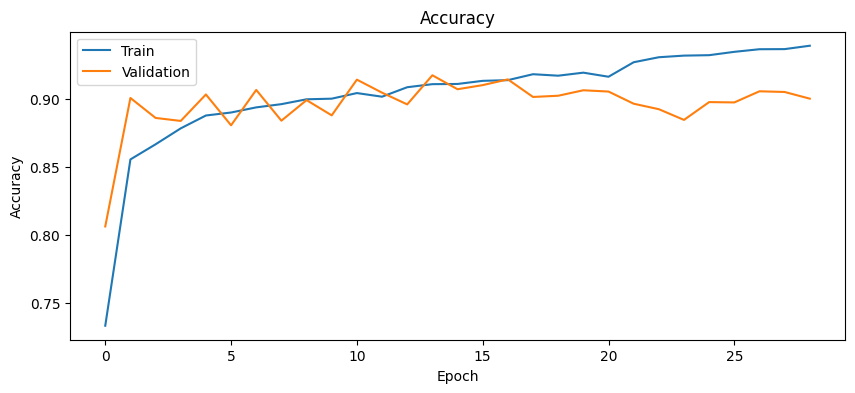

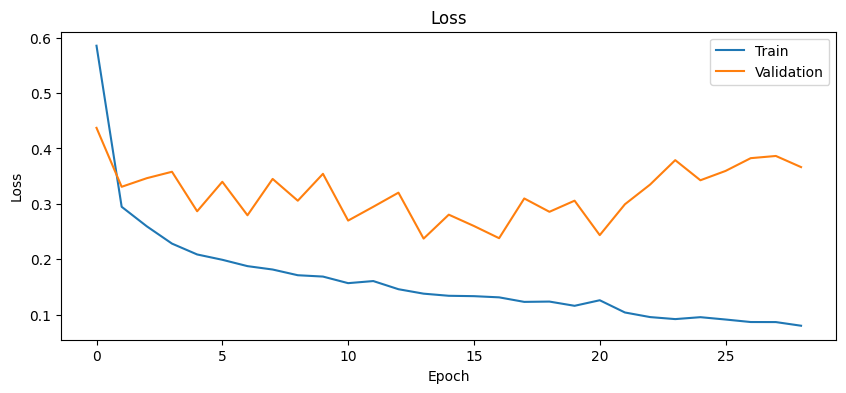

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()
plt.show()

## 20. Đánh giá trên Test Set

In [23]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import tensorflow as tf

best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

test_loss, test_acc = best_model.evaluate(
    X_test,
    y_test,
    batch_size=256,
    verbose=1
)

print(f"\nTest loss     : {test_loss:.6f}")
print(f"Test accuracy : {test_acc:.4%}")

y_prob = best_model.predict(
    X_test,
    batch_size=256,
    verbose=1
)

y_pred = np.argmax(y_prob, axis=1)

report = classification_report(
    y_test,
    y_pred,
    target_names=CLASS_NAMES,
    digits=4
)

print("\n" + report)

with open(OUTPUT_DIR / "classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report)

59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9248 - loss: 0.2088

Test loss     : 0.208763
Test accuracy : 92.4810%
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step

              precision    recall  f1-score   support

        Walk     0.8832    0.8780    0.8806      4452
         Run     0.9629    0.9723    0.9676      2163
  Static/ADL     0.9380    0.9334    0.9357      7730
        Fall     0.9243    0.9773    0.9501       750

    accuracy                         0.9248     15095
   macro avg     0.9271    0.9403    0.9335     15095
weighted avg     0.9247    0.9248    0.9247     15095



## 21. Confusion Matrix

[[3909   64  474    5]
 [  59 2103    1    0]
 [ 458    2 7215   55]
 [   0   15    2  733]]


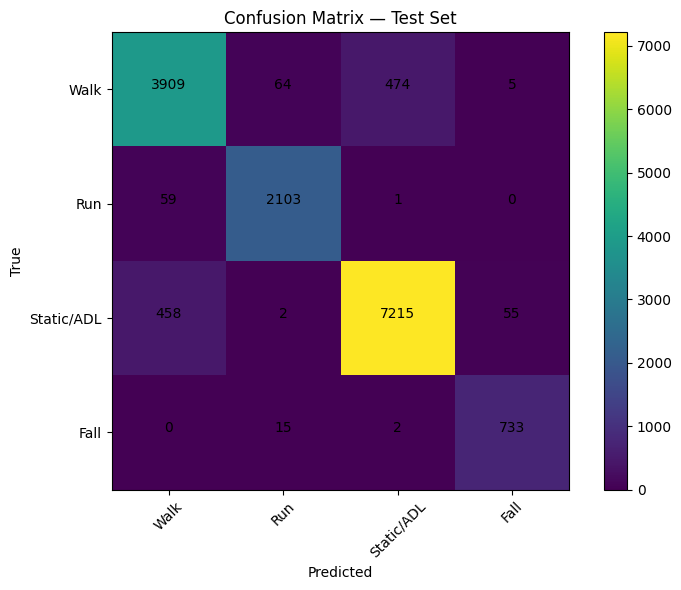

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest")
plt.title("Confusion Matrix — Test Set")
plt.colorbar()

ticks = np.arange(len(CLASS_NAMES))
plt.xticks(ticks, CLASS_NAMES, rotation=45)
plt.yticks(ticks, CLASS_NAMES)

threshold = cm.max() / 2

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j,
            i,
            str(cm[i, j]),
            horizontalalignment="center"
        )

plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

## 22. Chỉ số quan trọng nhất: Fall

Không chỉ nhìn Accuracy. Với bài toán fall detection hãy xem:

- Fall Recall: bỏ sót bao nhiêu cú ngã
- Fall Precision: báo động giả bao nhiêu
- Fall F1

In [25]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_test,
    y_pred,
    labels=[0, 1, 2, 3],
    zero_division=0
)

fall = 3

print("===== FALL METRICS =====")
print(f"Support   : {support[fall]}")
print(f"Precision : {precision[fall]*100:.2f}%")
print(f"Recall    : {recall[fall]*100:.2f}%")
print(f"F1        : {f1[fall]*100:.2f}%")

===== FALL METRICS =====
Support   : 750
Precision : 92.43%
Recall    : 97.73%
F1        : 95.01%


## 23. Test một window đơn lẻ

Dùng để kiểm tra pipeline inference.

In [26]:
def predict_csv(csv_path):
    df = pd.read_csv(csv_path)

    x = df[REQUIRED_COLUMNS].to_numpy(dtype=np.float32)

    if x.shape != (200, 6):
        raise ValueError(f"Expected (200,6), got {x.shape}")

    x = np.expand_dims(x, axis=0)

    prob = best_model.predict(x, verbose=0)[0]
    pred = int(np.argmax(prob))

    print("Prediction:", CLASS_NAMES[pred])

    for i, name in enumerate(CLASS_NAMES):
        print(f"{name:12s}: {prob[i]*100:7.3f}%")

# Ví dụ:
predict_csv(ALL_FILES[0])

Prediction: Walk
Walk        :  99.122%
Run         :   0.010%
Static/ADL  :   0.867%
Fall        :   0.001%


# PHẦN C — DÙNG VỚI MPU6500 CỦA BẠN

Model này mong đợi **đúng thứ tự**:

```text
ax, ay, az, gx, gy, gz
```

và đơn vị:

```text
ax ay az : g
gx gy gz : degree/s
```

Dữ liệu MPU6500 bạn vừa đo có dạng:

```text
ax ≈ -0.10
ay ≈ -0.77
az ≈ -0.66
gx ≈ -3
gy ≈ 1
gz ≈ 0
```

đúng loại đơn vị cần thiết.

Realtime:

- sampling 100 Hz
- ring buffer 200 sample
- mỗi 50 sample chạy inference một lần
- input shape `(1, 200, 6)`

## 24. Export TFLite — optional

Chạy sau khi model `.keras` đã ổn.

In [33]:
import subprocess
from pathlib import Path

MODEL_PATH = OUTPUT_DIR / "best_model_cnn_lstm_6axis.keras"

TFLITE_PATH = (
    OUTPUT_DIR /
    "fall_detection_6axis_float32_frozen.tflite"
)

script = f'''
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import numpy as np

from tensorflow.python.framework.convert_to_constants import (
    convert_variables_to_constants_v2
)

MODEL_PATH = r"{MODEL_PATH}"
TFLITE_PATH = r"{TFLITE_PATH}"

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))


# =========================================================
# 1. LOAD MODEL
# =========================================================

model = tf.keras.models.load_model(
    MODEL_PATH,
    compile=False
)

print("✅ Loaded original model")


# =========================================================
# 2. CHECK AGAINST ORIGINAL REFERENCE
# =========================================================

x_ref = np.load("/tmp/x_ref.npy")
pred_ref = np.load("/tmp/pred_ref.npy")

pred_cpu = model.predict(
    x_ref,
    verbose=0
)

print("\\n===== KERAS CHECK =====")

print(
    "Max diff:",
    np.max(
        np.abs(pred_cpu - pred_ref)
    )
)

print(
    "Same classes:",
    np.array_equal(
        np.argmax(pred_cpu, axis=1),
        np.argmax(pred_ref, axis=1)
    )
)


# =========================================================
# 3. STATIC INPUT = 1 x 200 x 6
# =========================================================

@tf.function(
    input_signature=[
        tf.TensorSpec(
            shape=[1, 200, 6],
            dtype=tf.float32,
            name="imu_input"
        )
    ]
)
def inference(x):

    return model(
        x,
        training=False
    )


concrete_func = inference.get_concrete_function()

print("\\n✅ Concrete function created")


# =========================================================
# 4. FREEZE VARIABLES -> CONSTANTS
#
# lower_control_flow=False:
# giữ WHILE của LSTM để TFLite converter xử lý
# =========================================================

frozen_func = convert_variables_to_constants_v2(
    concrete_func,
    lower_control_flow=False
)

print("✅ Graph frozen")


# =========================================================
# 5. CHECK GRAPH
# =========================================================

ops = [
    op.type
    for op in frozen_func.graph.get_operations()
]

read_variable_count = ops.count("ReadVariableOp")
variable_count = sum(
    1
    for x in ops
    if "Variable" in x
)

print("\\n===== FROZEN GRAPH CHECK =====")
print("ReadVariableOp:", read_variable_count)
print("Variable-like ops:", variable_count)

if read_variable_count != 0:
    raise RuntimeError(
        "Graph vẫn còn ReadVariableOp"
    )


# =========================================================
# 6. CHECK FROZEN GRAPH OUTPUT
# =========================================================

sample = tf.constant(
    x_ref[0:1],
    dtype=tf.float32
)

frozen_output = frozen_func(sample)

# Có TF version trả list
if isinstance(
    frozen_output,
    (list, tuple)
):
    frozen_output = frozen_output[0]

frozen_pred = frozen_output.numpy()

keras_pred = model(
    sample,
    training=False
).numpy()

print("\\n===== KERAS vs FROZEN =====")

print(
    "Max diff:",
    np.max(
        np.abs(
            keras_pred -
            frozen_pred
        )
    )
)

print(
    "Same class:",
    np.argmax(keras_pred)
    ==
    np.argmax(frozen_pred)
)


# =========================================================
# 7. CONVERT FROZEN GRAPH TO PURE TFLITE
# =========================================================

converter = (
    tf.lite.TFLiteConverter
    .from_concrete_functions(
        [frozen_func]
    )
)

converter.target_spec.supported_ops = [
    tf.lite.OpsSet.TFLITE_BUILTINS
]

print("\\n===== CONVERT =====")

tflite_model = converter.convert()

with open(
    TFLITE_PATH,
    "wb"
) as f:

    f.write(tflite_model)


print("\\n✅ TFLITE CREATED")

print(
    "Saved:",
    TFLITE_PATH
)

print(
    "Size:",
    len(tflite_model) / 1024,
    "KiB"
)


# =========================================================
# 8. LOAD TFLITE
# =========================================================

interpreter = tf.lite.Interpreter(
    model_path=TFLITE_PATH
)

interpreter.allocate_tensors()

input_details = (
    interpreter
    .get_input_details()
)

output_details = (
    interpreter
    .get_output_details()
)


print("\\n===== INPUT =====")

print(
    "shape:",
    input_details[0]["shape"]
)

print(
    "dtype:",
    input_details[0]["dtype"]
)


print("\\n===== OUTPUT =====")

print(
    "shape:",
    output_details[0]["shape"]
)

print(
    "dtype:",
    output_details[0]["dtype"]
)


# =========================================================
# 9. REAL INFERENCE TEST
# =========================================================

sample_np = (
    x_ref[0:1]
    .astype(np.float32)
)

interpreter.set_tensor(
    input_details[0]["index"],
    sample_np
)

interpreter.invoke()

lite_pred = interpreter.get_tensor(
    output_details[0]["index"]
)


print("\\n===== KERAS vs TFLITE =====")

print("Keras:")
print(keras_pred[0])

print("\\nTFLite:")
print(lite_pred[0])


diff = np.max(
    np.abs(
        keras_pred -
        lite_pred
    )
)

print(
    "\\nMax diff:",
    diff
)

print(
    "Keras class:",
    np.argmax(keras_pred)
)

print(
    "TFLite class:",
    np.argmax(lite_pred)
)

print(
    "Same class:",
    np.argmax(keras_pred)
    ==
    np.argmax(lite_pred)
)

'''

script_path = Path(
    "/tmp/convert_frozen.py"
)

script_path.write_text(script)

result = subprocess.run(
    [
        "python",
        str(script_path)
    ],
    capture_output=True,
    text=True
)

print(result.stdout)

if result.stderr:
    print(
        "\\n===== STDERR ====="
    )
    print(result.stderr)

print(
    "\\nReturn code:",
    result.returncode
)

TensorFlow: 2.20.0
GPU: []
✅ Loaded original model

===== KERAS CHECK =====
Max diff: 1.7881393e-07
Same classes: True

✅ Concrete function created
✅ Graph frozen

===== FROZEN GRAPH CHECK =====
ReadVariableOp: 0
Variable-like ops: 0

===== KERAS vs FROZEN =====
Max diff: 0.0
Same class: True

===== CONVERT =====

✅ TFLITE CREATED
Saved: /content/drive/MyDrive/SisFall_training_output/fall_detection_6axis_float32_frozen.tflite
Size: 709.421875 KiB

===== INPUT =====
shape: [  1 200   6]
dtype: <class 'numpy.float32'>

===== OUTPUT =====
shape: [1 4]
dtype: <class 'numpy.float32'>

===== KERAS vs TFLITE =====
Keras:
[3.1132960e-01 6.1152317e-04 6.8794793e-01 1.1094432e-04]

TFLite:
[3.11329573e-01 6.11523166e-04 6.87947929e-01 1.10944224e-04]

Max diff: 2.9802322e-08
Keras class: 2
TFLite class: 2
Same class: True

\n===== STDERR =====
2026-09-23 15:13:32.156592: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to

# Kết luận

Dataset được coi là cắt đúng khi phần validator cho:

```text
Structure : PASS
Overlap   : PASS
Fall peak : PASS
Units     : PASS

DATASET READY FOR TRAINING
```

Nếu một mục FAIL/CHECK, **không train vội**. Giữ lại output và xem đúng mục nào sai.

In [34]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

interpreter = tf.lite.Interpreter(
    model_path=str(
        OUTPUT_DIR /
        "fall_detection_6axis_float32_frozen.tflite"
    )
)

interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

y_pred_tflite = []

for i in range(len(X_test)):
    x = X_test[i:i+1].astype(np.float32)

    interpreter.set_tensor(
        input_details[0]["index"],
        x
    )

    interpreter.invoke()

    output = interpreter.get_tensor(
        output_details[0]["index"]
    )[0]

    y_pred_tflite.append(
        np.argmax(output)
    )

y_pred_tflite = np.array(y_pred_tflite)

print(
    classification_report(
        y_test,
        y_pred_tflite,
        target_names=[
            "Walk",
            "Run",
            "Static/ADL",
            "Fall"
        ],
        digits=4
    )
)

print("\nConfusion matrix:")
print(
    confusion_matrix(
        y_test,
        y_pred_tflite
    )
)

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


              precision    recall  f1-score   support

        Walk     0.8832    0.8780    0.8806      4452
         Run     0.9629    0.9723    0.9676      2163
  Static/ADL     0.9380    0.9334    0.9357      7730
        Fall     0.9243    0.9773    0.9501       750

    accuracy                         0.9248     15095
   macro avg     0.9271    0.9403    0.9335     15095
weighted avg     0.9247    0.9248    0.9247     15095


Confusion matrix:
[[3909   64  474    5]
 [  59 2103    1    0]
 [ 458    2 7215   55]
 [   0   15    2  733]]
